In [116]:
import sys, os
sys.path.insert(0, os.path.abspath("../../"))   # project root → plot_style.py

import numpy as np
import matplotlib.pyplot as plt

from plot_style import apply_style, C, FIG
apply_style()

In [117]:
# ── Parameters ──────────────────────────────────────────────────────────────
g  = 9.81
dt = 86_400

hs = 0.20   # snow layer height [m]  — 10 cm fresh snowfall

# Δsnow
eta0_ds    = 8.523e6
k_ds       = 0.030
rho0_ds    = 81
rho_max_ds = 401
rho_ds     = np.linspace(rho0_ds, 560, 500)
x_ds       = rho_ds / rho0_ds

# ΔSnow self-weight overburden [kg m⁻²], varies with rho
sh_ds      = rho_ds * hs

# HS2SWE
eta0_hs    = 6.051e7
c1         = 2.8e-6
c3         = 0.046
c5         = 0.018
rho0_hs    = 113.7
rho_max_hs = 571.6
rho_hs     = np.linspace(rho0_hs, 560, 500)
x_hs       = rho_hs / rho0_hs

# HS2SWE self-weight overburden [kg m⁻²], varies with rho
sh_hs      = rho_hs * hs

x_lim    = 5.1          # normalised x upper limit
sh_const = 200          # [kg m⁻²] constant OVB for panel 2

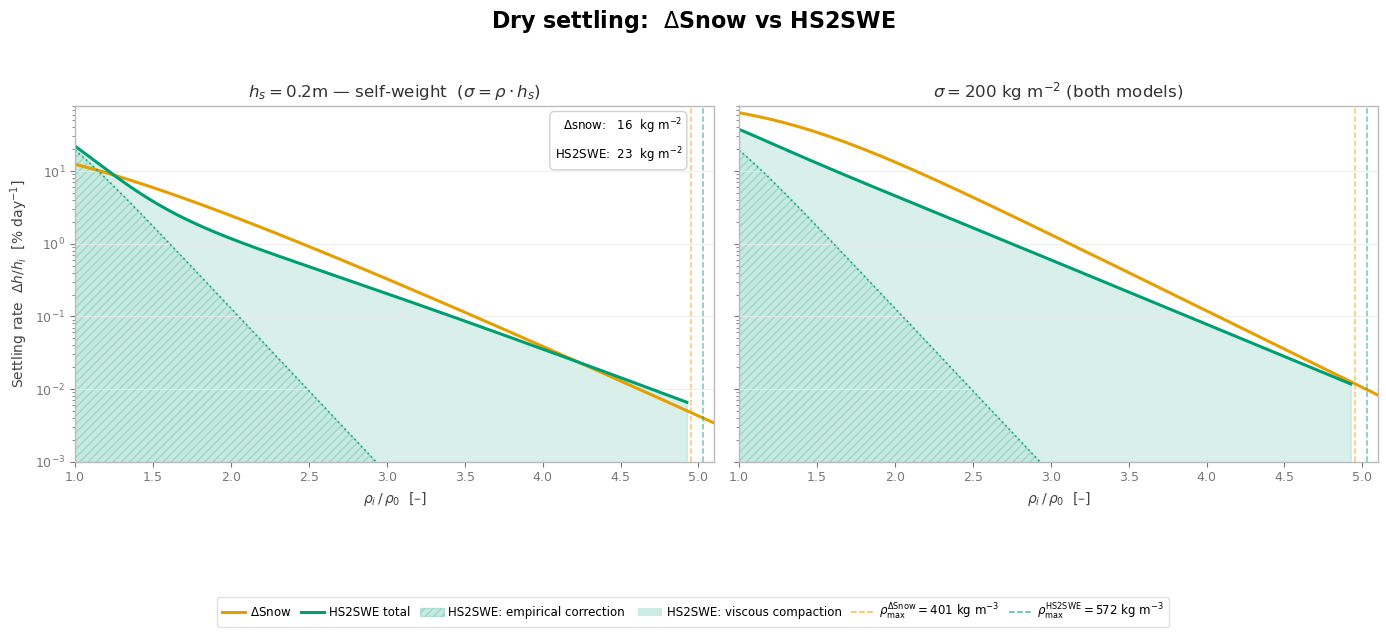

In [118]:
def eps_ds(rho, sh):
    return (sh * g / eta0_ds) * np.exp(-k_ds * rho)

def eps_hs_term1(rho, sh):
    return (sh * g / eta0_hs) * np.exp(-c5 * rho)

def eps_hs_term2(rho):
    return c1 * np.exp(-c3 * np.maximum(0, rho - rho0_hs))

def eps_hs(rho, sh):
    return eps_hs_term1(rho, sh) + eps_hs_term2(rho)

def dh(eps):
    return (1 - 1 / (1 + eps * dt)) * 100   # % per day

# ── Precompute (σ-independent) ────────────────────────────────────────────────
dh_t2    = dh(eps_hs_term2(rho_hs))
x_max_ds = rho_max_ds / rho0_ds
x_max_hs = rho_max_hs / rho0_hs

from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

def draw_panel(ax, sh_arr_ds, sh_arr_hs, title, show_ylabel=True, swe_infobox=False):
    y_ds  = dh(eps_ds(rho_ds, sh_arr_ds))
    y_hs  = dh(eps_hs(rho_hs, sh_arr_hs))
    y_floor = 1e-4

    # ── ΔSnow — line only ─────────────────────────────────────────────────────
    ax.plot(x_ds, y_ds, color=C.DSNOW, lw=2.2, linestyle="-")

    # ── HS2SWE — stacked fills + lines ───────────────────────────────────────
    ax.fill_between(x_hs, y_floor, dh_t2,
                    color=C.HS2SWE, alpha=0.22, hatch="////",
                    edgecolor=C.HS2SWE, linewidth=0.0)
    ax.fill_between(x_hs, np.maximum(dh_t2, y_floor), y_hs,
                    color=C.HS2SWE, alpha=0.15)
    ax.plot(x_hs, dh_t2, color=C.HS2SWE, lw=1.3, linestyle=":", alpha=0.8)
    ax.plot(x_hs, y_hs,  color=C.HS2SWE, lw=2.2, linestyle="-")

    # ── ρ_max vertical lines ──────────────────────────────────────────────────
    ax.axvline(x_max_ds, color=C.DSNOW,  lw=1.1, linestyle="--", alpha=0.55)
    ax.axvline(x_max_hs, color=C.HS2SWE, lw=1.1, linestyle="--", alpha=0.55)

    # ── SWE info box (top-right, panel 1 only) ────────────────────────────────
    if swe_infobox:
        swe_ds_lo = rho0_ds       * hs          # at x=1
        swe_ds_hi = x_lim * rho0_ds * hs        # at x=x_lim
        swe_hs_lo = rho0_hs       * hs
        swe_hs_hi = x_lim * rho0_hs * hs
        box_txt = (
            rf"$\Delta$snow:   {swe_ds_lo:.0f}  kg m$^{{-2}}$" + "\n"
            rf"HS2SWE:  {swe_hs_lo:.0f}  kg m$^{{-2}}$"
        )
        ax.text(0.95, 0.97, box_txt,
                transform=ax.transAxes,
                ha="right", va="top", fontsize=8.5,
                linespacing=1.7,
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                          edgecolor="#CCCCCC", alpha=0.9))

    ax.set_yscale("log")
    ax.set_xlabel(r"$\rho_i\,/\,\rho_0$  [–]")
    if show_ylabel:
        ax.set_ylabel(r"Settling rate  $\Delta h / h_i$  [% day$^{-1}$]")
    ax.set_xlim(1, x_lim)
    ax.set_ylim(bottom=1e-3, top=80)
    ax.set_title(title)

draw_panel(axes[0],
           sh_arr_ds=sh_ds, sh_arr_hs=sh_hs,
           title=rf"$h_s={hs}$m — self-weight  ($\sigma=\rho\cdot h_s$)",
           show_ylabel=True, swe_infobox=True)

draw_panel(axes[1],
           sh_arr_ds=np.full_like(rho_ds, sh_const),
           sh_arr_hs=np.full_like(rho_hs, sh_const),
           title=rf"$\sigma={sh_const}$ kg m$^{{-2}}$ (both models)",
           show_ylabel=False, swe_infobox=False)

# ── Single legend at bottom ───────────────────────────────────────────────────
legend_handles = [
    Line2D([0],[0], color=C.DSNOW,  lw=2.2, linestyle="-",
           label=r"$\Delta$Snow"),
    Line2D([0],[0], color=C.HS2SWE, lw=2.2, linestyle="-",
           label="HS2SWE total"),
    Patch(facecolor=C.HS2SWE, alpha=0.22, hatch="////", edgecolor=C.HS2SWE,
          label=r"HS2SWE: empirical correction "),
    Patch(facecolor=C.HS2SWE, alpha=0.20,
          label=r"HS2SWE: viscous compaction"),
    Line2D([0],[0], color=C.DSNOW,  lw=1.1, linestyle="--", alpha=0.7,
           label=rf"$\rho_\mathrm{{max}}^{{\Delta\mathrm{{Snow}}}}={rho_max_ds:.0f}$ kg m$^{{-3}}$"),
    Line2D([0],[0], color=C.HS2SWE, lw=1.1, linestyle="--", alpha=0.7,
           label=rf"$\rho_\mathrm{{max}}^\mathrm{{HS2SWE}}={rho_max_hs:.0f}$ kg m$^{{-3}}$"),
]

fig.legend(handles=legend_handles, loc="lower center", ncols=6,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.22),
           columnspacing=0.8, handletextpad=0.4)

fig.suptitle(r"Dry settling:  $\Delta$Snow vs HS2SWE", y=1.03)
plt.tight_layout()
plt.savefig("dSnow_HS2SWE_densification_rate.png", **FIG.SAVE)
plt.show()

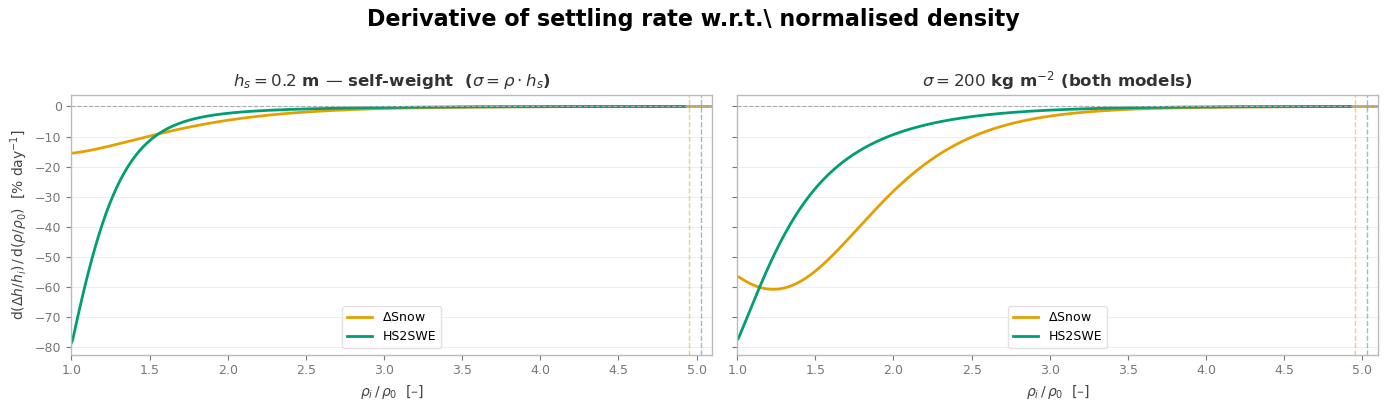

In [119]:
# ── Derivative of the two main settling curves w.r.t. normalised density ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, sh_arr_ds, sh_arr_hs, title in [
    (axes[0], sh_ds, sh_hs,
     rf"$h_s={hs}$ m — self-weight  ($\sigma=\rho\cdot h_s$)"),
    (axes[1], np.full_like(rho_ds, sh_const), np.full_like(rho_hs, sh_const),
     rf"$\sigma={sh_const}$ kg m$^{{-2}}$ (both models)"),
]:
    y_ds = dh(eps_ds(rho_ds, sh_arr_ds))
    y_hs = dh(eps_hs(rho_hs, sh_arr_hs))

    dy_ds = np.gradient(y_ds, x_ds)
    dy_hs = np.gradient(y_hs, x_hs)

    ax.plot(x_ds, dy_ds, color=C.DSNOW,  lw=2.0, label=r"$\Delta$Snow")
    ax.plot(x_hs, dy_hs, color=C.HS2SWE, lw=2.0, label="HS2SWE")
    ax.axhline(0, color="#AAAAAA", lw=0.8, linestyle="--")

    ax.axvline(x_max_ds, color=C.DSNOW,  lw=1.0, linestyle="--", alpha=0.5)
    ax.axvline(x_max_hs, color=C.HS2SWE, lw=1.0, linestyle="--", alpha=0.5)

    ax.set_xlim(1, x_lim)
    ax.set_xlabel(r"$\rho_i\,/\,\rho_0$  [–]")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

axes[0].set_ylabel(
    r"$\mathrm{d}(\Delta h/h_i)\,/\,\mathrm{d}(\rho/\rho_0)$  [% day$^{-1}$]"
)
fig.suptitle(r"Derivative of settling rate w.r.t.\ normalised density", y=1.02)
plt.tight_layout()
plt.show()